In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

print("TensorFlow version:", tf.__version__)

columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes',
    'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
    'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login',
    'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
    'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
    'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty'
]

train = pd.read_csv('../data/KDDTrain+.txt', names=columns).drop(columns=['difficulty'])
test  = pd.read_csv('../data/KDDTest+.txt',  names=columns).drop(columns=['difficulty'])

# Encode categoricals
cat_cols = ['protocol_type', 'service', 'flag']
le = LabelEncoder()
for col in cat_cols:
    combined = pd.concat([train[col], test[col]])
    le.fit(combined)
    train[col] = le.transform(train[col])
    test[col]  = le.transform(test[col])

# Binary label: 0 = normal, 1 = attack (any type)
train['binary_label'] = (train['label'] != 'normal').astype(int)
test['binary_label']  = (test['label']  != 'normal').astype(int)

feature_names = [c for c in train.columns if c not in ['label', 'binary_label']]

X_train_all = train[feature_names]
y_train_all = train['binary_label']
X_test      = test[feature_names]
y_test      = test['binary_label']

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_all)
X_test_scaled  = scaler.transform(X_test)

# KEY: train autoencoder ONLY on normal traffic
X_train_normal = X_train_scaled[y_train_all == 0]
print(f"Training autoencoder on {X_train_normal.shape[0]} normal samples only")
print(f"Test set: {X_test_scaled.shape[0]} samples ({y_test.sum()} attacks)")

TensorFlow version: 2.21.0
Training autoencoder on 67343 normal samples only
Test set: 22544 samples (12833 attacks)


In [4]:
input_dim = X_train_normal.shape[1]  # 41

inputs  = Input(shape=(input_dim,))

# Encoder — compress 41 features down to 8
x = Dense(32, activation='relu')(inputs)
x = Dense(16, activation='relu')(x)
encoded = Dense(8, activation='relu')(x)

# Decoder — reconstruct back to 41 features
x = Dense(16, activation='relu')(encoded)
x = Dense(32, activation='relu')(x)
decoded = Dense(input_dim, activation='linear')(x)

autoencoder = Model(inputs, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 41)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 41)             │         1,353 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,049 (15.82 KB)

 Trainable params: 4,049 (15.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.6748 - val_loss: 0.3696
Epoch 2/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4594 - val_loss: 0.2469
Epoch 3/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3554 - val_loss: 0.1741
Epoch 4/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3033 - val_loss: 0.1443
Epoch 5/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2735 - val_loss: 0.1293
Epoch 6/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2506 - val_loss: 0.1518
Epoch 7/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2483 - val_loss: 0.1143
Epoch 8/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2128 - val_loss: 0.1145
Epoch 9/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1932 - val_loss: 0.1025
Epoch 10/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1833 - val_loss: 0.1090
Epoch 11/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1666 - val_loss: 0.1266
Epoch 12/50
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

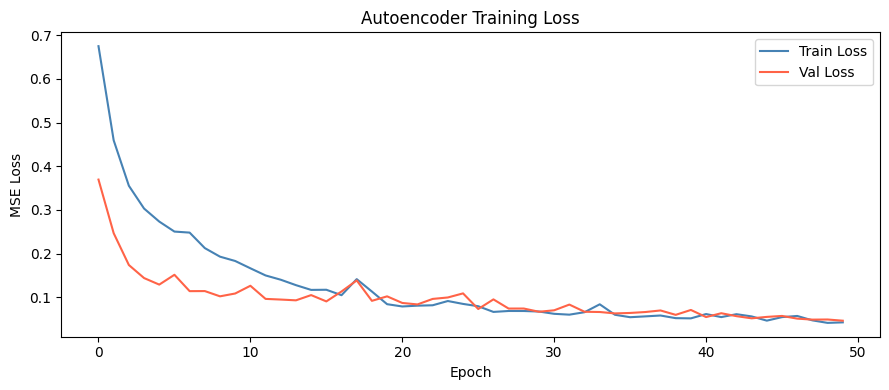

In [5]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = autoencoder.fit(
    X_train_normal, X_train_normal,  # input = output (reconstruction)
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# Plot training loss
plt.figure(figsize=(9, 4))
plt.plot(history.history['loss'],     label='Train Loss', color='steelblue')
plt.plot(history.history['val_loss'], label='Val Loss',   color='tomato')
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.savefig('../autoencoder_loss.png', dpi=150)
plt.show()

Anomaly threshold (95th percentile): 0.144235


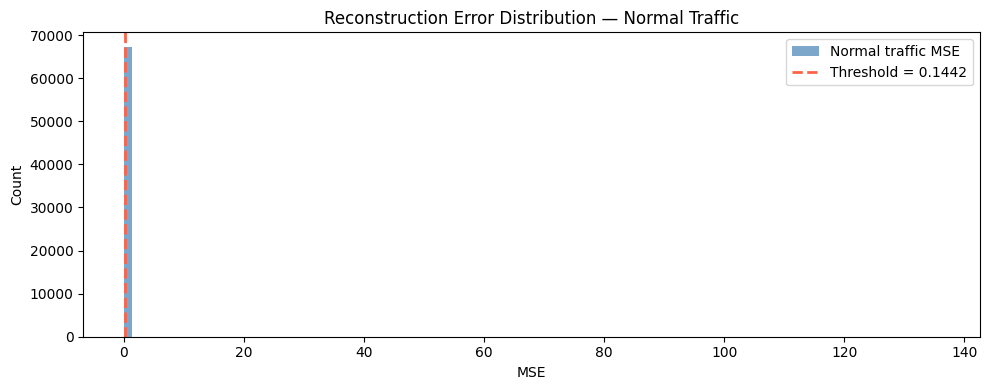

In [6]:
# Reconstruction error on normal training data
train_recon   = autoencoder.predict(X_train_normal, verbose=0)
train_mse     = np.mean(np.power(X_train_normal - train_recon, 2), axis=1)

# Threshold = 95th percentile of normal reconstruction error
threshold = np.percentile(train_mse, 95)
print(f"Anomaly threshold (95th percentile): {threshold:.6f}")

# Plot error distribution
plt.figure(figsize=(10, 4))
plt.hist(train_mse, bins=100, color='steelblue', alpha=0.7, label='Normal traffic MSE')
plt.axvline(threshold, color='tomato', linestyle='--', linewidth=2,
            label=f'Threshold = {threshold:.4f}')
plt.title('Reconstruction Error Distribution — Normal Traffic')
plt.xlabel('MSE')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('../autoencoder_threshold.png', dpi=150)
plt.show()

In [7]:
test_recon = autoencoder.predict(X_test_scaled, verbose=0)
test_mse   = np.mean(np.power(X_test_scaled - test_recon, 2), axis=1)

# Flag as anomaly if reconstruction error > threshold
y_pred = (test_mse > threshold).astype(int)

print("=== Autoencoder Anomaly Detection Results ===")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

auc = roc_auc_score(y_test, test_mse)
print(f"ROC-AUC Score: {auc:.4f}")

=== Autoencoder Anomaly Detection Results ===
              precision    recall  f1-score   support

      Normal       0.75      0.92      0.83      9711
      Attack       0.93      0.77      0.84     12833

    accuracy                           0.83     22544
   macro avg       0.84      0.84      0.83     22544
weighted avg       0.85      0.83      0.83     22544

ROC-AUC Score: 0.9506


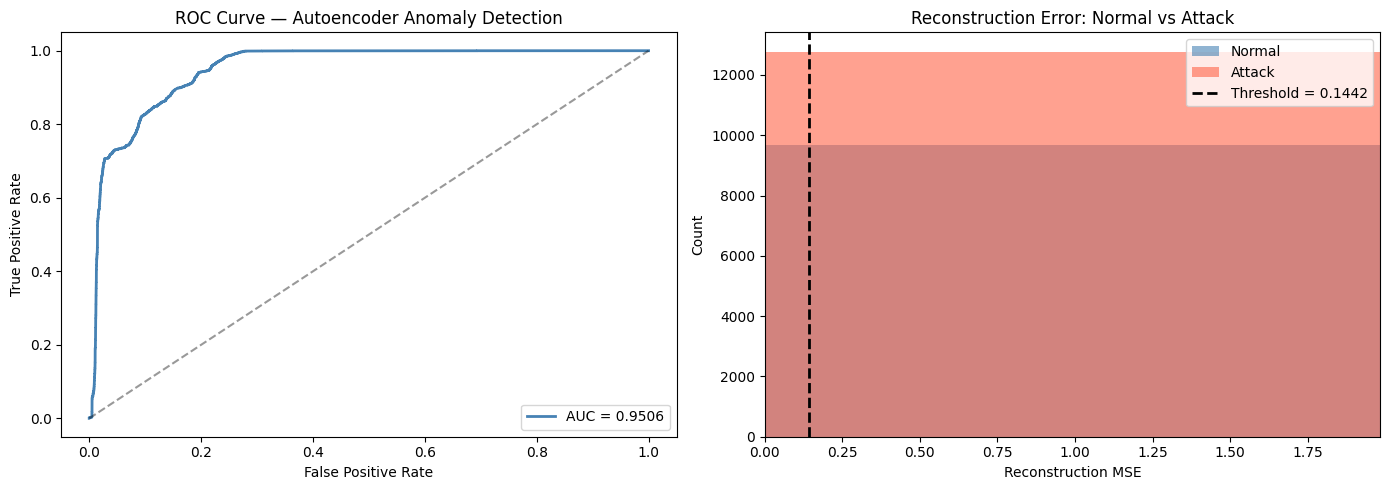

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_mse)
axes[0].plot(fpr, tpr, color='steelblue', linewidth=2,
             label=f'AUC = {auc:.4f}')
axes[0].plot([0,1], [0,1], 'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Autoencoder Anomaly Detection')
axes[0].legend()

# Reconstruction error: normal vs attack
normal_mse = test_mse[y_test == 0]
attack_mse = test_mse[y_test == 1]

axes[1].hist(normal_mse, bins=80, alpha=0.6, color='steelblue', label='Normal')
axes[1].hist(attack_mse, bins=80, alpha=0.6, color='tomato',    label='Attack')
axes[1].axvline(threshold, color='black', linestyle='--', linewidth=2,
                label=f'Threshold = {threshold:.4f}')
axes[1].set_xlabel('Reconstruction MSE')
axes[1].set_ylabel('Count')
axes[1].set_title('Reconstruction Error: Normal vs Attack')
axes[1].legend()
axes[1].set_xlim(0, np.percentile(test_mse, 99))

plt.tight_layout()
plt.savefig('../autoencoder_results.png', dpi=150)
plt.show()

In [9]:
# Simulate zero-day: test on attack types the supervised model never handled well
# Use the raw test labels to break down autoencoder performance by attack family

dos   = ['back','land','neptune','pod','smurf','teardrop']
probe = ['ipsweep','nmap','portsweep','satan']
r2l   = ['ftp_write','guess_passwd','imap','multihop','phf','spy','warezclient','warezmaster']
u2r   = ['buffer_overflow','loadmodule','perl','rootkit']

def map_label(label):
    if label == 'normal': return 'normal'
    if label in dos:      return 'DoS'
    if label in probe:    return 'Probe'
    if label in r2l:      return 'R2L'
    if label in u2r:      return 'U2R'
    return 'zero-day'     # unseen attack types

test_families = test['label'].apply(map_label)

print(f"{'Attack Family':<15} {'Samples':>8} {'Detected':>10} {'Detection Rate':>15}")
print('-' * 52)

for family in ['normal', 'DoS', 'Probe', 'R2L', 'U2R', 'zero-day']:
    mask    = test_families == family
    if mask.sum() == 0:
        continue
    flagged = y_pred[mask].sum()
    total   = mask.sum()
    rate    = flagged / total
    print(f"{family:<15} {total:>8} {flagged:>10} {rate:>14.1%}")

Attack Family    Samples   Detected  Detection Rate
----------------------------------------------------
normal              9711        776           8.0%
DoS                 5741       5377          93.7%
Probe               1106        855          77.3%
R2L                 2199        726          33.0%
U2R                   37         25          67.6%
zero-day            3750       2865          76.4%


Epoch 1/150


237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0404 - val_loss: 0.0412
Epoch 2/150
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0339 - val_loss: 0.0490
Epoch 3/150
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0390 - val_loss: 0.0414
Epoch 4/150
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0345 - val_loss: 0.0425
Epoch 5/150
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0356 - val_loss: 0.0411
Epoch 6/150
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0349 - val_loss: 0.0501
Epoch 7/150
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0390 - val_loss: 0.0402
Epoch 8/150
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0346 - val_loss: 0.0401
Epoch 9/150
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0341 - val_loss: 0.0413
Epoch 10/150
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0393 - val_loss: 0.0381
Epoch 11/150
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0423 - val_loss: 0.0523
Epoch 12/150
237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

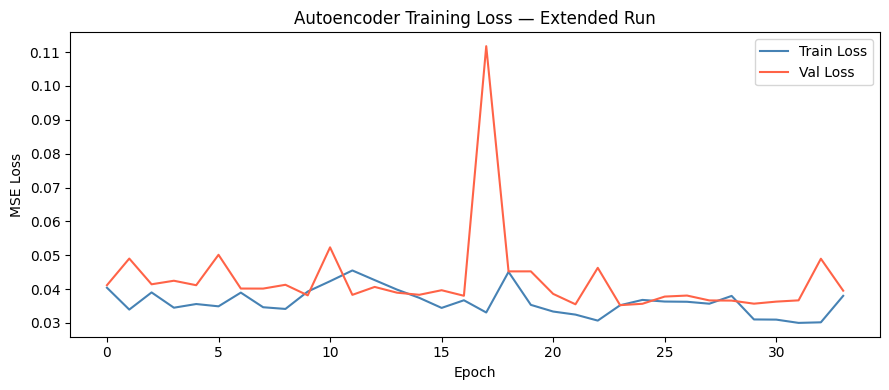

In [15]:
# Retrain with 150 epochs — previous run never converged
early_stop2 = EarlyStopping(monitor='val_loss', patience=10, 
                             restore_best_weights=True)

history2 = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=150,
    batch_size=256,
    validation_split=0.1,
    callbacks=[early_stop2],
    verbose=1
)

final_epoch = len(history2.history['loss'])
print(f"\nEarly stopping triggered at epoch {final_epoch}")

plt.figure(figsize=(9, 4))
plt.plot(history2.history['loss'],     label='Train Loss', color='steelblue')
plt.plot(history2.history['val_loss'], label='Val Loss',   color='tomato')
plt.title('Autoencoder Training Loss — Extended Run')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.savefig('../autoencoder_loss_v2.png', dpi=150)
plt.show()

In [16]:
# Recompute reconstruction errors with improved model
from sklearn.metrics import f1_score, recall_score, precision_score, classification_report, roc_auc_score

train_recon2 = autoencoder.predict(X_train_normal, verbose=0)
train_mse2   = np.mean(np.power(X_train_normal - train_recon2, 2), axis=1)

test_recon2  = autoencoder.predict(X_test_scaled, verbose=0)
test_mse2    = np.mean(np.power(X_test_scaled - test_recon2, 2), axis=1)

# Try percentiles from 80 to 99 — find which gives best F1
percentiles = np.arange(80, 100, 1)
results = []

for p in percentiles:
    thresh   = np.percentile(train_mse2, p)
    y_pred_p = (test_mse2 > thresh).astype(int)
    f1       = f1_score(y_test, y_pred_p, average='macro')
    rec      = recall_score(y_test, y_pred_p, average='macro')
    prec     = precision_score(y_test, y_pred_p, average='macro')
    results.append((p, thresh, f1, rec, prec))

results_df2 = pd.DataFrame(results, 
    columns=['Percentile', 'Threshold', 'Macro F1', 'Recall', 'Precision'])
print(results_df2.to_string(index=False))

best     = results_df2.loc[results_df2['Macro F1'].idxmax()]
best_thresh2 = best['Threshold']
print(f"\nBest percentile: {best['Percentile']:.0f}  |  "
      f"Threshold: {best_thresh2:.6f}  |  Macro F1: {best['Macro F1']:.4f}")

# Final evaluation with best threshold
y_pred_final = (test_mse2 > best_thresh2).astype(int)
print("\n=== FINAL Autoencoder (optimised threshold) ===")
print(classification_report(y_test, y_pred_final, target_names=['Normal', 'Attack']))
print(f"ROC-AUC: {roc_auc_score(y_test, test_mse2):.4f}")

# Zero-day breakdown with new model
print(f"\n{'Attack Family':<15} {'Samples':>8} {'Detected':>10} {'Detection Rate':>15}")
print('-' * 52)
for family in ['normal', 'DoS', 'Probe', 'R2L', 'U2R', 'zero-day']:
    mask    = test_families == family
    if mask.sum() == 0:
        continue
    flagged = y_pred_final[mask].sum()
    total   = mask.sum()
    print(f"{family:<15} {total:>8} {flagged:>10} {flagged/total:>14.1%}")

 Percentile  Threshold  Macro F1   Recall  Precision
         80   0.018884  0.883256 0.879649   0.889168
         81   0.020463  0.881063 0.878604   0.884564
         82   0.022362  0.874635 0.874103   0.875214
         83   0.024448  0.876139 0.876172   0.876107
         84   0.026296  0.875506 0.876097   0.874970
         85   0.028492  0.867828 0.869674   0.866527
         86   0.031003  0.865888 0.868642   0.864326
         87   0.033562  0.865534 0.868802   0.863922
         88   0.037167  0.865479 0.869596   0.863931
         89   0.041034  0.863081 0.868236   0.861875
         90   0.046704  0.863560 0.870233   0.863254
         91   0.052368  0.869788 0.878147   0.870919
         92   0.059365  0.872925 0.882574   0.875527
         93   0.069035  0.870728 0.881013   0.874256
         94   0.081039  0.868086 0.879050   0.872697
         95   0.098373  0.863739 0.875792   0.870273
         96   0.118828  0.851874 0.865748   0.862228
         97   0.153453  0.834989 0.851529   0.

Epoch 1/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.8153 - val_loss: 0.5835
Epoch 2/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6829 - val_loss: 0.4679
Epoch 3/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6034 - val_loss: 0.3913
Epoch 4/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5541 - val_loss: 0.3336
Epoch 5/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.5153 - val_loss: 0.2952
Epoch 6/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4890 - val_loss: 0.2701
Epoch 7/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.4583 - val_loss: 0.2502
Epoch 8/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4582 - val_loss: 0.2382
Epoch 9/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4325 - val_loss: 0.2192
Epoch 10/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4126 - val_loss: 0.2078
Epoch 11/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4002 - val_loss: 0.1999
Epoch 12/200
119/119 ━━━━━━━━━━━━━━━━━━━━

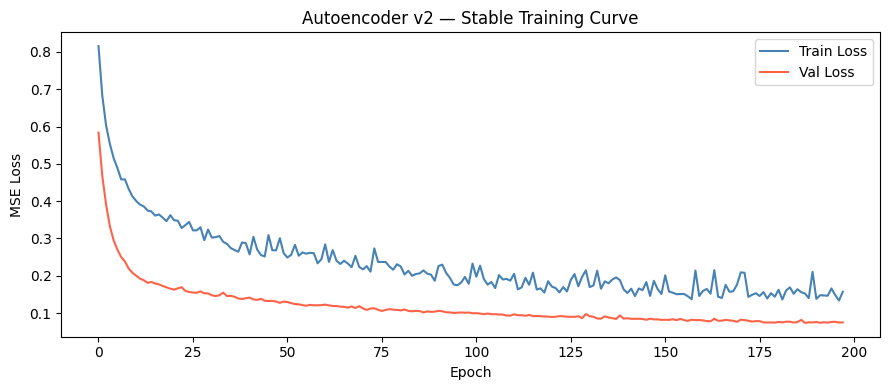

In [17]:
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam

input_dim = X_train_normal.shape[1]

inputs  = Input(shape=(input_dim,))

# Encoder
x = Dense(32, activation='relu')(inputs)
x = Dropout(0.1)(x)
x = Dense(16, activation='relu')(x)
x = Dropout(0.1)(x)
encoded = Dense(12, activation='relu')(x)  # slightly wider bottleneck

# Decoder
x = Dense(16, activation='relu')(encoded)
x = Dropout(0.1)(x)
x = Dense(32, activation='relu')(x)
decoded = Dense(input_dim, activation='linear')(x)

autoencoder_v2 = Model(inputs, decoded)
autoencoder_v2.compile(optimizer=Adam(learning_rate=0.0005), loss='mse')

early_stop3 = EarlyStopping(monitor='val_loss', patience=10,
                             restore_best_weights=True)

history3 = autoencoder_v2.fit(
    X_train_normal, X_train_normal,
    epochs=200,
    batch_size=512,
    validation_split=0.1,
    callbacks=[early_stop3],
    verbose=1
)

final_epoch = len(history3.history['loss'])
print(f"\nEarly stopping triggered at epoch {final_epoch}")

plt.figure(figsize=(9, 4))
plt.plot(history3.history['loss'],     label='Train Loss', color='steelblue')
plt.plot(history3.history['val_loss'], label='Val Loss',   color='tomato')
plt.title('Autoencoder v2 — Stable Training Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.savefig('../autoencoder_loss_v3.png', dpi=150)
plt.show()

In [19]:
from sklearn.metrics import f1_score, recall_score, precision_score, classification_report, roc_auc_score

train_recon3 = autoencoder_v2.predict(X_train_normal, verbose=0)
train_mse3   = np.mean(np.power(X_train_normal - train_recon3, 2), axis=1)

test_recon3  = autoencoder_v2.predict(X_test_scaled, verbose=0)
test_mse3    = np.mean(np.power(X_test_scaled - test_recon3, 2), axis=1)

# Find best threshold
percentiles = np.arange(80, 100, 1)
best_f1, best_thresh3, best_p = 0, 0, 0

for p in percentiles:
    thresh   = np.percentile(train_mse3, p)
    y_pred_p = (test_mse3 > thresh).astype(int)
    f1       = f1_score(y_test, y_pred_p, average='macro')
    if f1 > best_f1:
        best_f1, best_thresh3, best_p = f1, thresh, p

print(f"Best percentile: {best_p}  |  Threshold: {best_thresh3:.6f}  |  Macro F1: {best_f1:.4f}")

y_pred_v2 = (test_mse3 > best_thresh3).astype(int)

print("\n=== Autoencoder v2 Results ===")
print(classification_report(y_test, y_pred_v2, target_names=['Normal', 'Attack']))
print(f"ROC-AUC: {roc_auc_score(y_test, test_mse3):.4f}")

# Zero-day breakdown
print(f"\n{'Attack Family':<15} {'Samples':>8} {'Detected':>10} {'Detection Rate':>15}")
print('-' * 52)
for family in ['normal', 'DoS', 'Probe', 'R2L', 'U2R', 'zero-day']:
    mask = test_families == family
    if mask.sum() == 0:
        continue
    flagged = y_pred_v2[mask].sum()
    total   = mask.sum()
    print(f"{family:<15} {total:>8} {flagged:>10} {flagged/total:>14.1%}")

# Compare v1 vs v2 — using known v1 results
print(f"\n{'Model':<30} {'ROC-AUC':>10} {'Macro F1':>10} {'Zero-day Det.':>15}")
print('-' * 68)
zd_v2 = y_pred_v2[test_families == 'zero-day'].sum() / (test_families == 'zero-day').sum()
print(f"{'Autoencoder v1 (lr=0.001)':<30} {'0.9506':>10} {'0.8300':>10} {'76.4%':>15}")
print(f"{'Autoencoder v2 (lr=0.0005)':<30} {roc_auc_score(y_test, test_mse3):>10.4f} {best_f1:>10.4f} {zd_v2:>14.1%}")

Best percentile: 84  |  Threshold: 0.100532  |  Macro F1: 0.8684

=== Autoencoder v2 Results ===
              precision    recall  f1-score   support

      Normal       0.86      0.84      0.85      9711
      Attack       0.88      0.89      0.89     12833

    accuracy                           0.87     22544
   macro avg       0.87      0.87      0.87     22544
weighted avg       0.87      0.87      0.87     22544

ROC-AUC: 0.9437

Attack Family    Samples   Detected  Detection Rate
----------------------------------------------------
normal              9711       1540          15.9%
DoS                 5741       5445          94.8%
Probe               1106       1103          99.7%
R2L                 2199       1377          62.6%
U2R                   37         27          73.0%
zero-day            3750       3517          93.8%

Model                             ROC-AUC   Macro F1   Zero-day Det.
--------------------------------------------------------------------
Autoencod